In [4]:
from IPython.utils import io

with io.capture_output():
    %run ../01_eda_exploratory_data_analysis/01_data_overview.ipynb
    %run ../01_eda_exploratory_data_analysis/02_statistical_analysis.ipynb

print("✅ Connected to notebooks")

✅ Connected to notebooks


### Prepare Data for Correlation

In [5]:
# ====================================================================
# 🔧 PREPARE DATA FOR CORRELATION ANALYSIS
# ====================================================================

# Ensure returns are calculated
if 'returns' not in df.columns and price_col:
    df['returns'] = df[price_col].pct_change() * 100
    df['cumulative'] = (df[price_col] / df[price_col].iloc[0] - 1) * 100
    print("✅ Calculated returns and cumulative columns")

# Define correlation columns
correlation_cols = []

# Price-related columns
for col in ['open', 'high', 'low', 'close', 'volume', 'returns', 'cumulative']:
    if col in df.columns:
        correlation_cols.append(col)

# Technical indicators
for col in ['RSI_14', 'MACD', 'MACD_signal', 'MACD_histogram', 'ATR_14']:
    if col in df.columns:
        correlation_cols.append(col)

# Moving averages
for col in ['SMA_7', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26']:
    if col in df.columns:
        correlation_cols.append(col)

# Bollinger Bands
for col in ['BB_middle', 'BB_upper', 'BB_lower']:
    if col in df.columns:
        correlation_cols.append(col)

print(f"📋 Selected {len(correlation_cols)} columns for correlation:")
for col in correlation_cols:
    print(f"  - {col}")

📋 Selected 19 columns for correlation:
  - open
  - high
  - low
  - close
  - volume
  - returns
  - RSI_14
  - MACD
  - MACD_signal
  - MACD_histogram
  - ATR_14
  - SMA_7
  - SMA_20
  - SMA_50
  - EMA_12
  - EMA_26
  - BB_middle
  - BB_upper
  - BB_lower


### Correlation Matrix

In [6]:
# ====================================================================
# 📊 CORRELATION MATRIX
# ====================================================================

print("=" * 60)
print("📊 CORRELATION MATRIX")
print("=" * 60)

# Create correlation matrix
corr_matrix = df[correlation_cols].corr()

# Display full matrix
print("\n📈 Full Correlation Matrix:")
display(corr_matrix)

# Save to CSV
try:
    exports_dir = Path('../../exports/reports')
    exports_dir.mkdir(parents=True, exist_ok=True)
    corr_matrix.to_csv(exports_dir / 'correlation_matrix.csv')
    print(f"\n✅ Correlation matrix saved to: {exports_dir / 'correlation_matrix.csv'}")
except Exception as e:
    print(f"\n⚠️ Could not save: {e}")

📊 CORRELATION MATRIX

📈 Full Correlation Matrix:


,open,high,low,close,volume,returns,RSI_14,MACD,MACD_signal,MACD_histogram,ATR_14,SMA_7,SMA_20,SMA_50,EMA_12,EMA_26,BB_middle,BB_upper,BB_lower
open,1.000000,0.997475,0.995835,0.994115,0.343994,-0.034500,0.151922,0.343656,0.378633,-0.029559,0.716161,0.993217,0.977474,0.933185,0.990358,0.975600,0.977474,0.951797,0.979349
high,0.997475,1.000000,0.995574,0.997671,0.363985,0.010164,0.160288,0.339934,0.372293,-0.022654,0.726507,0.992735,0.978144,0.937384,0.990267,0.975913,0.978144,0.954193,0.977864
low,0.995835,0.995574,1.000000,0.997506,0.292576,0.022863,0.175596,0.358455,0.387510,-0.008987,0.698265,0.988565,0.971082,0.921221,0.985454,0.968971,0.971082,0.942712,0.976486
close,0.994115,0.997671,0.997506,1.000000,0.326215,0.053646,0.175254,0.348197,0.377622,-0.012262,0.711870,0.989474,0.974057,0.929338,0.986926,0.971594,0.974057,0.948137,0.976338
volume,0.343994,0.363985,0.292576,0.326215,1.000000,-0.166070,-0.216951,-0.189199,-0.118650,-0.247826,0.520108,0.289274,0.306094,0.340790,0.305749,0.333378,0.306094,0.370491,0.217089
returns,-0.034500,0.010164,0.022863,0.053646,-0.166070,1.000000,0.258766,0.071596,0.029775,0.138233,0.002715,0.038508,0.011720,-0.014477,0.034499,0.027476,0.011720,0.008161,0.015763
RSI_14,0.151922,0.160288,0.175596,0.175254,-0.216951,0.258766,1.000000,0.644118,0.462592,0.678543,-0.158873,0.109403,-0.047562,-0.179180,0.066397,-0.003125,-0.047562,-0.101353,0.020420
MACD,0.343656,0.339934,0.358455,0.348197,-0.189199,0.071596,0.644118,1.000000,0.948547,0.364608,-0.136340,0.310952,0.140362,-0.291713,0.261202,0.158196,0.140362,0.061230,0.233940
MACD_signal,0.378633,0.372293,0.387510,0.377622,-0.118650,0.029775,0.462592,0.948547,1.000000,0.051009,-0.062991,0.366168,0.242593,-0.223936,0.327672,0.231797,0.242593,0.172669,0.321658
MACD_histogram,-0.029559,-0.022654,-0.008987,-0.012262,-0.247826,0.138233,0.678543,0.364608,0.051009,1.000000,-0.248176,-0.096193,-0.305419,-0.250930,-0.139758,-0.182701,-0.305419,-0.345838,-0.246091



✅ Correlation matrix saved to: ..\..\exports\reports\correlation_matrix.csv


### Correlation Heatmap

🔥 CORRELATION HEATMAP


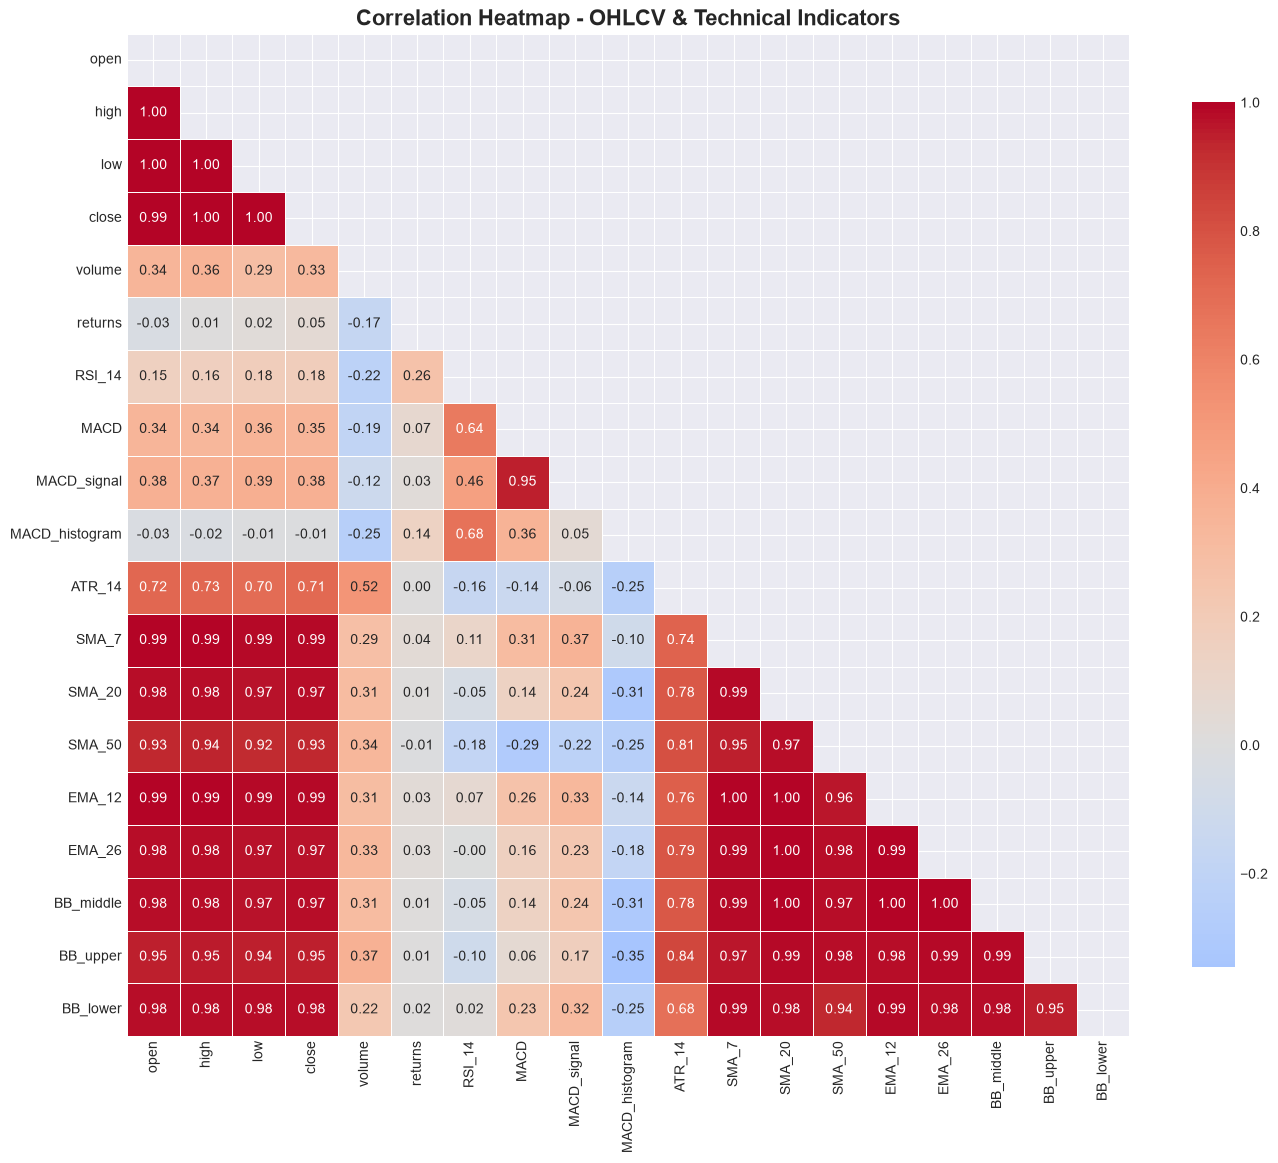


✅ Heatmap displayed


In [7]:
# ====================================================================
# 🔥 CORRELATION HEATMAP
# ====================================================================

print("=" * 60)
print("🔥 CORRELATION HEATMAP")
print("=" * 60)

fig, ax = plt.subplots(figsize=(14, 12))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create heatmap
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            ax=ax)

ax.set_title('Correlation Heatmap - OHLCV & Technical Indicators', 
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Heatmap displayed")

### Top Correlations with Close Price

In [8]:
# ====================================================================
# 📊 TOP CORRELATIONS WITH CLOSE PRICE
# ====================================================================

print("=" * 60)
print("📊 TOP CORRELATIONS WITH CLOSE PRICE")
print("=" * 60)

if 'close' in corr_matrix.columns:
    # Get correlations with close price
    close_corr = corr_matrix['close'].sort_values(ascending=False)
    
    print("\n📈 Correlations with Close Price:")
    print("-" * 50)
    for col, value in close_corr.items():
        if col != 'close':
            print(f"  {col:20s} : {value:+.4f}")
    
    # Strong positive correlations
    strong_pos = close_corr[close_corr > 0.7]
    strong_neg = close_corr[close_corr < -0.7]
    
    print("\n🔍 Strong Positive Correlations (>0.7):")
    for col, value in strong_pos.items():
        if col != 'close':
            print(f"  {col:20s} : {value:+.4f}")
    
    print("\n🔍 Strong Negative Correlations (<-0.7):")
    for col, value in strong_neg.items():
        if col != 'close':
            print(f"  {col:20s} : {value:+.4f}")

📊 TOP CORRELATIONS WITH CLOSE PRICE

📈 Correlations with Close Price:
--------------------------------------------------
  high                 : +0.9977
  low                  : +0.9975
  open                 : +0.9941
  SMA_7                : +0.9895
  EMA_12               : +0.9869
  BB_lower             : +0.9763
  SMA_20               : +0.9741
  BB_middle            : +0.9741
  EMA_26               : +0.9716
  BB_upper             : +0.9481
  SMA_50               : +0.9293
  ATR_14               : +0.7119
  MACD_signal          : +0.3776
  MACD                 : +0.3482
  volume               : +0.3262
  RSI_14               : +0.1753
  returns              : +0.0536
  MACD_histogram       : -0.0123

🔍 Strong Positive Correlations (>0.7):
  high                 : +0.9977
  low                  : +0.9975
  open                 : +0.9941
  SMA_7                : +0.9895
  EMA_12               : +0.9869
  BB_lower             : +0.9763
  SMA_20               : +0.9741
  BB_middle   

### Correlation with Returns

In [9]:
# ====================================================================
# 📊 CORRELATIONS WITH RETURNS
# ====================================================================

print("=" * 60)
print("📊 CORRELATIONS WITH RETURNS")
print("=" * 60)

if 'returns' in corr_matrix.columns:
    returns_corr = corr_matrix['returns'].sort_values(ascending=False)
    
    print("\n📈 Correlations with Returns:")
    print("-" * 50)
    for col, value in returns_corr.items():
        if col != 'returns':
            print(f"  {col:20s} : {value:+.4f}")
    
    # Top 5 correlations with returns
    top5 = returns_corr.head(6)  # includes returns itself
    print("\n🔍 Top 5 Correlations with Returns:")
    for col, value in top5.items():
        if col != 'returns':
            print(f"  {col:20s} : {value:+.4f}")

📊 CORRELATIONS WITH RETURNS

📈 Correlations with Returns:
--------------------------------------------------
  RSI_14               : +0.2588
  MACD_histogram       : +0.1382
  MACD                 : +0.0716
  close                : +0.0536
  SMA_7                : +0.0385
  EMA_12               : +0.0345
  MACD_signal          : +0.0298
  EMA_26               : +0.0275
  low                  : +0.0229
  BB_lower             : +0.0158
  BB_middle            : +0.0117
  SMA_20               : +0.0117
  high                 : +0.0102
  BB_upper             : +0.0082
  ATR_14               : +0.0027
  SMA_50               : -0.0145
  open                 : -0.0345
  volume               : -0.1661

🔍 Top 5 Correlations with Returns:
  RSI_14               : +0.2588
  MACD_histogram       : +0.1382
  MACD                 : +0.0716
  close                : +0.0536
  SMA_7                : +0.0385


### Feature Correlation Analysis

In [10]:
# ====================================================================
# 📊 FEATURE CORRELATION ANALYSIS
# ====================================================================

print("=" * 60)
print("📊 FEATURE CORRELATION ANALYSIS")
print("=" * 60)

# Analyze correlations between features
print("\n🔍 High Feature Correlations (>0.9 or <-0.9):")
print("-" * 50)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.9:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr_pairs.append((col1, col2, val))
            print(f"  {col1:15s} ↔ {col2:15s} : {val:+.4f}")

if not high_corr_pairs:
    print("  No extremely high correlations found")

print("\n🔍 Medium Feature Correlations (0.7-0.9 or -0.7 to -0.9):")
print("-" * 50)

medium_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if 0.7 < abs(val) <= 0.9:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            medium_corr_pairs.append((col1, col2, val))
            print(f"  {col1:15s} ↔ {col2:15s} : {val:+.4f}")

if not medium_corr_pairs:
    print("  No medium correlations found")

📊 FEATURE CORRELATION ANALYSIS

🔍 High Feature Correlations (>0.9 or <-0.9):
--------------------------------------------------
  open            ↔ high            : +0.9975
  open            ↔ low             : +0.9958
  open            ↔ close           : +0.9941
  open            ↔ SMA_7           : +0.9932
  open            ↔ SMA_20          : +0.9775
  open            ↔ SMA_50          : +0.9332
  open            ↔ EMA_12          : +0.9904
  open            ↔ EMA_26          : +0.9756
  open            ↔ BB_middle       : +0.9775
  open            ↔ BB_upper        : +0.9518
  open            ↔ BB_lower        : +0.9793
  high            ↔ low             : +0.9956
  high            ↔ close           : +0.9977
  high            ↔ SMA_7           : +0.9927
  high            ↔ SMA_20          : +0.9781
  high            ↔ SMA_50          : +0.9374
  high            ↔ EMA_12          : +0.9903
  high            ↔ EMA_26          : +0.9759
  high            ↔ BB_middle       : +0.978

### Pairplot of Key Features

📊 PAIRPLOT OF KEY FEATURES

📋 Pairplot columns: ['close', 'volume', 'returns', 'RSI_14', 'MACD']


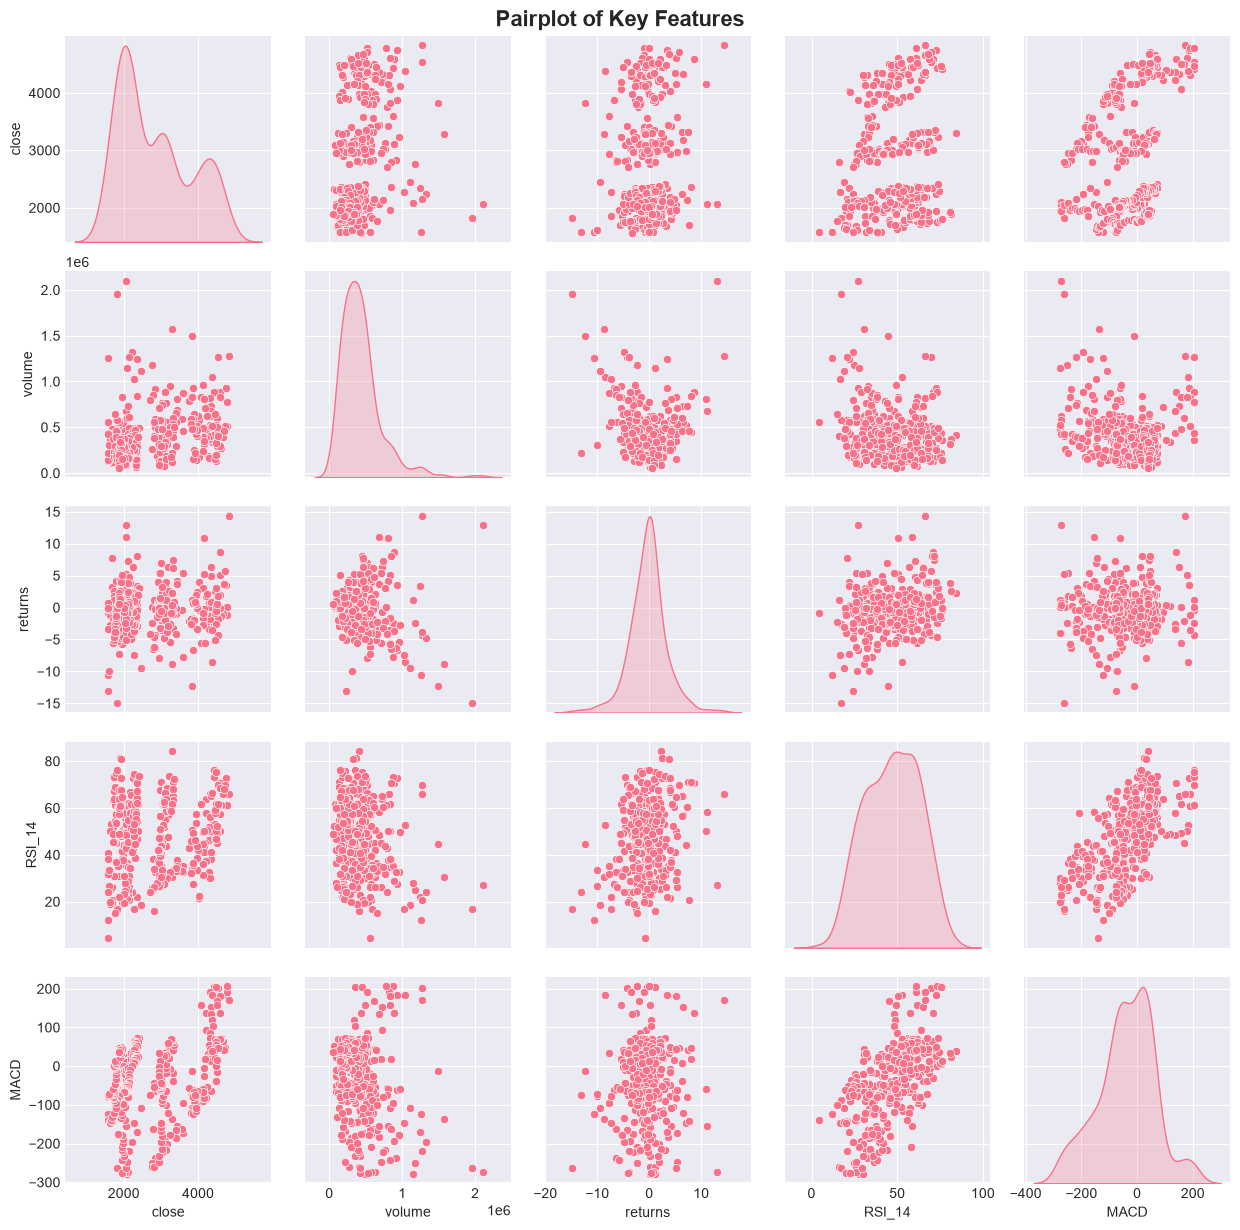

In [11]:
# ====================================================================
# 📊 PAIRPLOT OF KEY FEATURES
# ====================================================================

print("=" * 60)
print("📊 PAIRPLOT OF KEY FEATURES")
print("=" * 60)

# Select key features for pairplot
pairplot_cols = ['close', 'volume', 'returns', 'RSI_14', 'MACD']

# Only include columns that exist
available_cols = [col for col in pairplot_cols if col in df.columns]

if len(available_cols) >= 2:
    print(f"\n📋 Pairplot columns: {available_cols}")
    
    # Create pairplot
    g = sns.pairplot(df[available_cols].dropna(), diag_kind='kde', height=2.5)
    g.fig.suptitle('Pairplot of Key Features', fontsize=16, fontweight='bold')
    g.fig.tight_layout()
    plt.show()
else:
    print("⚠️  Not enough columns for pairplot (need at least 2)")
    print(f"Available columns: {available_cols}")

### Scatter Plots with Close Price

📈 SCATTER PLOTS WITH CLOSE PRICE


TypeError: expected x and y to have same length

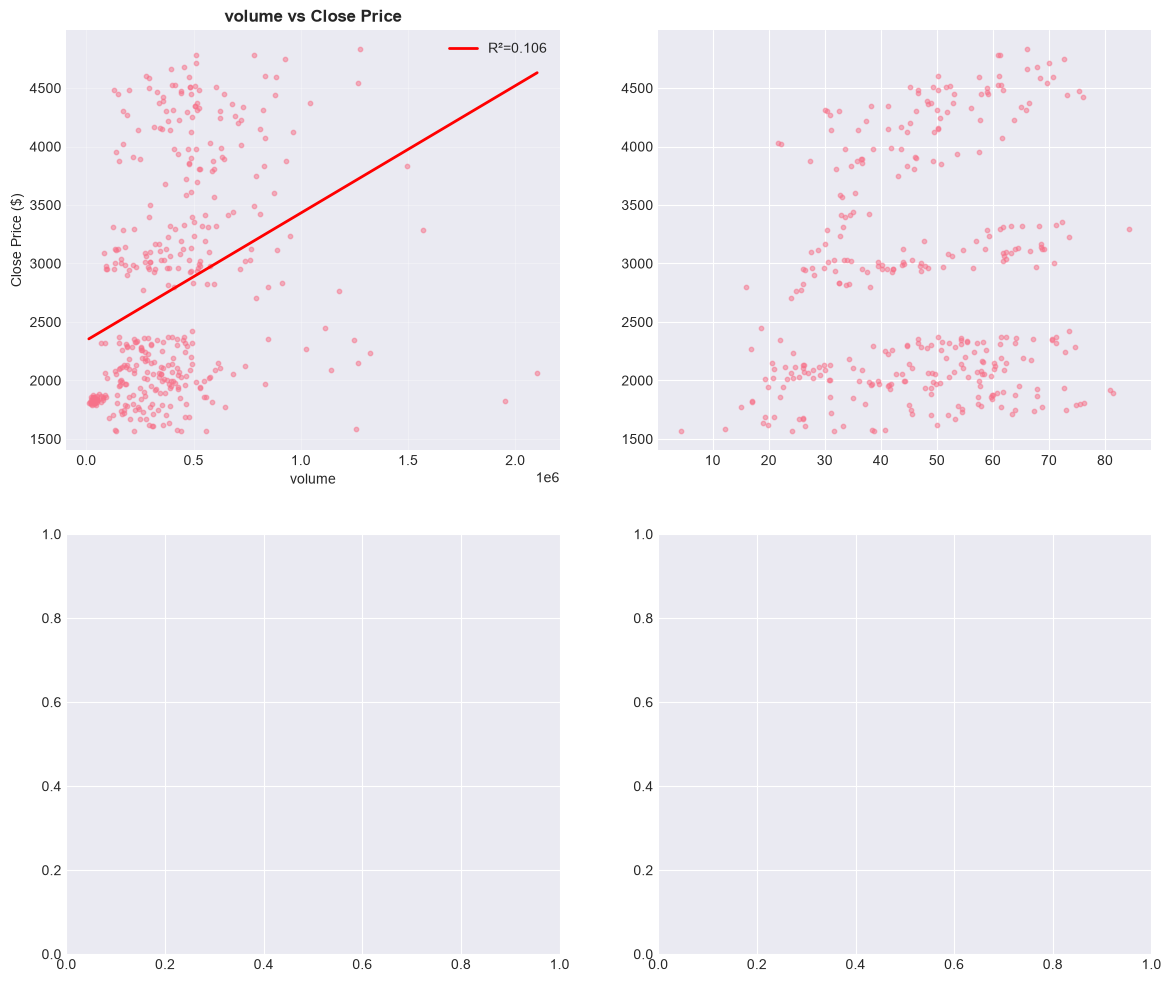

In [12]:
# ====================================================================
# 📈 SCATTER PLOTS WITH CLOSE PRICE
# ====================================================================

print("=" * 60)
print("📈 SCATTER PLOTS WITH CLOSE PRICE")
print("=" * 60)

# Select features to plot against close price
scatter_features = []
for col in ['volume', 'RSI_14', 'MACD', 'ATR_14']:
    if col in df.columns:
        scatter_features.append(col)

if scatter_features:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for idx, feature in enumerate(scatter_features):
        if idx < len(axes):
            ax = axes[idx]
            # Scatter plot
            ax.scatter(df[feature], df['close'], alpha=0.5, s=10)
            
            # Add trend line
            z = np.polyfit(df[feature].dropna(), df['close'].dropna(), 1)
            p = np.poly1d(z)
            ax.plot(df[feature].sort_values(), 
                   p(df[feature].sort_values()), 
                   color='red', linewidth=2, label=f'R²={np.corrcoef(df[feature].dropna(), df["close"].dropna())[0,1]**2:.3f}')
            
            ax.set_xlabel(feature)
            ax.set_ylabel('Close Price ($)')
            ax.set_title(f'{feature} vs Close Price', fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    # Remove empty subplots
    for idx in range(len(scatter_features), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No scatter plot features available")

### Correlation Summary Report